In [ ]:
import os, sys, subprocess
from pathlib import Path

MARKER = Path("/tmp/finn_deps_done")
PINNED = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.13.1",
    "scikit-learn==1.5.2",
    "statsmodels==0.14.2",
    "yfinance>=0.2.60",
    "curl_cffi",
    "arch",              
    "loguru", "tqdm", "pyyaml",
]
print()


if not MARKER.exists():
    print("→ Uninstalling any stale numpy/pandas/scipy (ignore 'not installed' warnings)…")
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-qy", "numpy", "pandas", "scipy"],
        check=False,
    )
    print("→ Installing pinned scientific stack in a single transaction…")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + PINNED
    )
    MARKER.touch()
else:
    print("✓ Deps already installed in this runtime (skipping reinstall).")

# If numpy/pandas were imported before we reinstalled, the kernel still has
# the broken copy in memory. Force a manual restart in that case.
_stale = []
if "numpy" in sys.modules and sys.modules["numpy"].__version__ != "1.26.4":
    _stale.append(f"numpy={sys.modules['numpy'].__version__}")
if "pandas" in sys.modules and sys.modules["pandas"].__version__ != "2.2.2":
    _stale.append(f"pandas={sys.modules['pandas'].__version__}")
if _stale:
    raise SystemExit(
        f"Stale modules in kernel memory ({', '.join(_stale)}). "
        "Use Runtime → Restart session, then re-run Cells 1–3."
    )

# ABI probe against the fresh install.
try:
    import numpy as np
    import pandas as pd
    pd.DataFrame({"a": [1, 2, 3]}).sum()  # exercises pandas→numpy ABI surface
    print(f"✓ NumPy/Pandas OK: numpy={np.__version__}, pandas={pd.__version__}")
except Exception as e:
    raise SystemExit(
        f"ABI probe still failing ({type(e).__name__}: {e}). "
        "Delete /tmp/finn_deps_done, Runtime → Restart session, then re-run."
    )

# --- Device report ------------------------------------------------------
try:
    _gpu = subprocess.run(
        ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
        capture_output=True, text=True, timeout=5,
    ).stdout.strip()
    print(f"  GPU: {_gpu or 'No GPU detected'}")
except (FileNotFoundError, subprocess.TimeoutExpired):
    print("  GPU: CPU-only runtime")

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"  torch device: {device}")
if device == "cuda":
    # torch attribute is `total_memory` (bytes), not `total_mem`.
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ Deps already installed in this runtime (skipping reinstall).
✓ NumPy/Pandas OK: numpy=1.26.4, pandas=2.2.2
  GPU: CPU-only runtime
  torch device: cpu


In [2]:
import os, sys, subprocess

if not os.path.exists("finn"):
    !git clone https://github.com/must1f/finn.git
else:
    !cd finn && git pull

sys.path.insert(0, "finn")
os.chdir("finn")

print(f"Working directory: {os.getcwd()}")


Cloning into 'finn'...
remote: Enumerating objects: 4789, done.
remote: Counting objects: 100% (464/464), done.
remote: Compressing objects: 100% (365/365), done.
remote: Total 4789 (delta 130), reused 373 (delta 97), pack-reused 4325 (from 3)
Receiving objects: 100% (4789/4789), 232.76 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (1153/1153), done.
Updating files: 100% (3425/3425), done.
Working directory: /content/finn


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Install lightweight deps if missing
try:
    import lightgbm as lgb
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Colorblind-safe Okabe-Ito palette
OKABE_ITO = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
sns.set_theme(style='ticks', context='paper', font_scale=1.3)
sns.set_palette(OKABE_ITO)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titlepad': 10,
    'axes.labelpad': 6,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'legend.fontsize': 9,
    'legend.framealpha': 0,
    'legend.borderpad': 0.4,
    'lines.linewidth': 1.8,
    'patch.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': False,  # managed per-figure
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})
print('Setup complete.')

Setup complete.


## Load Data

In [ ]:
from src.data.fetcher import DataFetcher
from src.data.features import compute_features

REPO = Path(os.getcwd())
fetcher = DataFetcher(cache_dir=Path(REPO) / 'data' / 'cache')
raw = fetcher.fetch(ticker='^GSPC', start='2010-01-01', end='2024-12-31')
vix = fetcher.fetch_close('^VIX', start='2010-01-01', end='2024-12-31')
tnx = fetcher.fetch_close('^TNX', start='2010-01-01', end='2024-12-31')
df = compute_features(raw, vix=vix, tnx=tnx)

FEATURE_COLS = [
    'log_return', 'simple_return',
    'rolling_volatility_5', 'rolling_volatility_20',
    'momentum_5', 'momentum_20',
    'rsi_14', 'macd', 'macd_signal',
    'bollinger_upper', 'bollinger_lower',
    'atr_14', 'volume_normalized', 'close_normalized',
    'vix_level', 'vix_change',
    'overnight_gap', 'rolling_skewness_20', 'vol_premium',
    'tnx_level', 'tnx_change',
]
TARGET_COL = 'log_return'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].shift(-1).dropna()
X = X.loc[y.index]

split = int(len(X) * 0.70)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler().fit(X_train)
Xs_train = pd.DataFrame(scaler.transform(X_train), columns=FEATURE_COLS, index=X_train.index)
Xs_test  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_COLS, index=X_test.index)

print(f'Full dataset : {len(X):,} rows   ({X.index[0].date()} → {X.index[-1].date()})')
print(f'Train        : {len(X_train):,} rows')
print(f'Test (OOS)   : {len(X_test):,} rows')
print(f'Features     : {len(FEATURE_COLS)}')

19:32:21 | INFO    | src.data.fetcher | Fetching ^GSPC from yfinance (2010-01-01 -> 2024-12-31)
19:32:22 | INFO    | src.data.fetcher | Cached 3773 rows -> GSPC_2010-01-01_2024-12-31.parquet
19:32:22 | INFO    | src.data.fetcher | Fetching ^VIX close from yfinance (2010-01-01 -> 2024-12-31)
19:32:22 | INFO    | src.data.fetcher | Cached 3773 rows -> VIX_close_2010-01-01_2024-12-31.parquet
19:32:22 | INFO    | src.data.fetcher | Fetching ^TNX close from yfinance (2010-01-01 -> 2024-12-31)
19:32:22 | INFO    | src.data.fetcher | Cached 3771 rows -> TNX_close_2010-01-01_2024-12-31.parquet
19:32:22 | INFO    | src.data.features | Features computed: 26 cols, dropped 20 warmup rows, 3753 rows remain


Full dataset : 3,752 rows   (2010-02-02 → 2024-12-27)
Train        : 2,626 rows
Test (OOS)   : 1,126 rows
Features     : 21


## Correlation Matrix

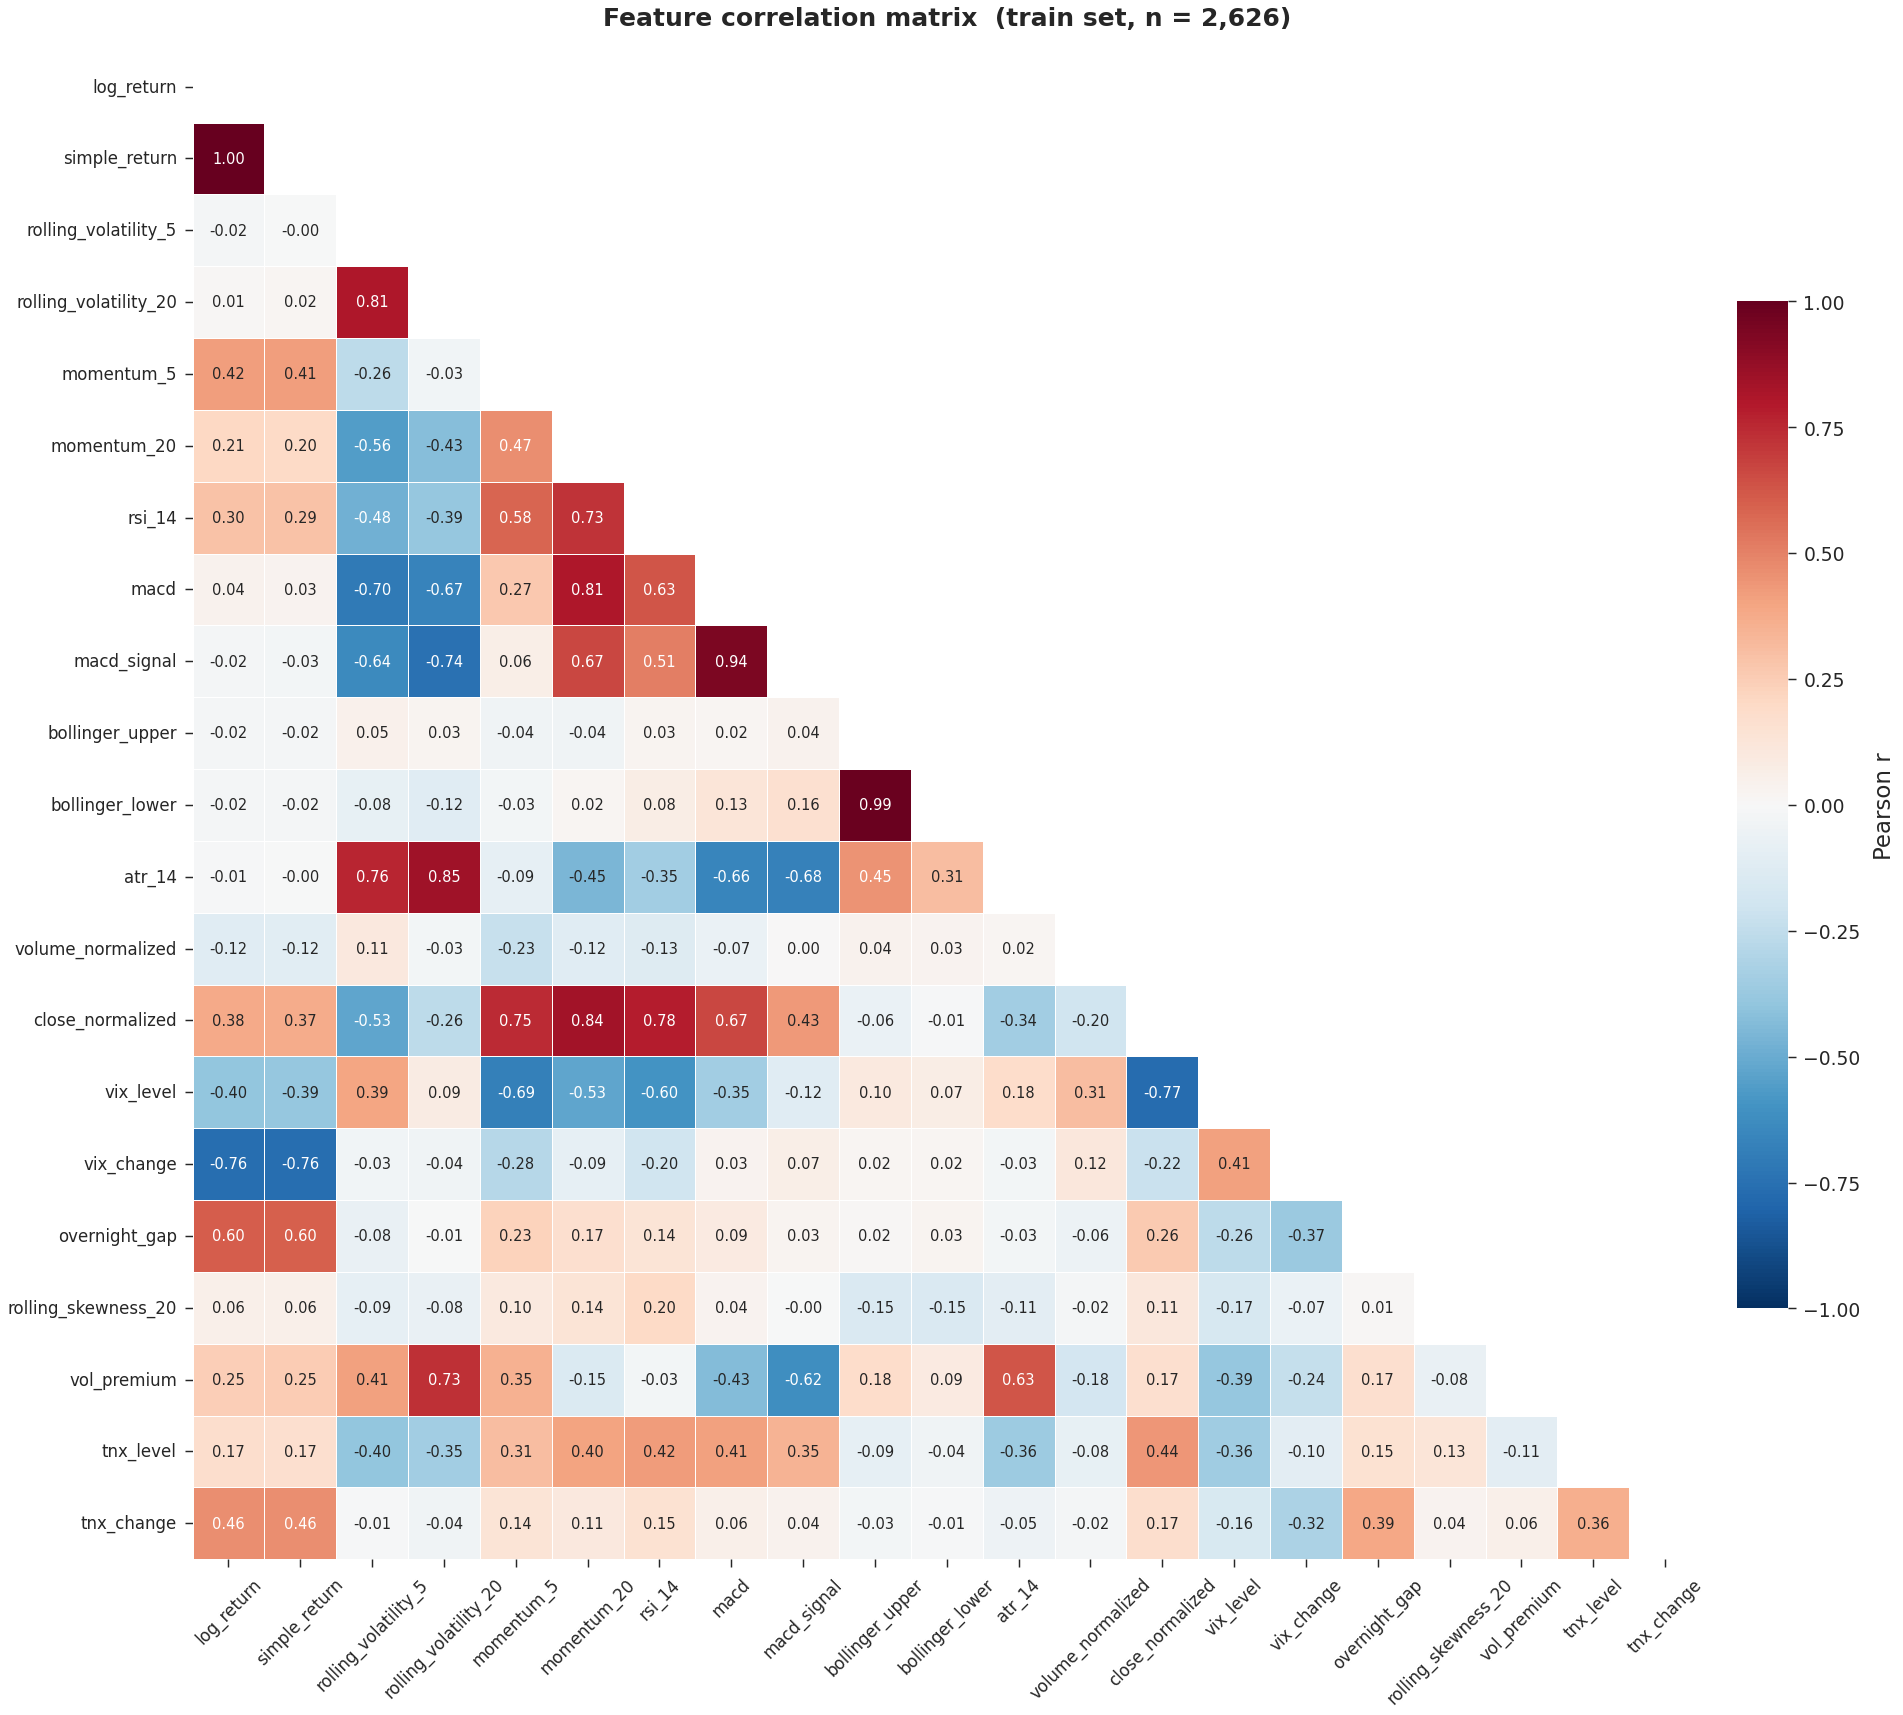

Pairs with |r| > 0.85:
  log_return                      ↔  simple_return                   r = +1.000
  bollinger_upper                 ↔  bollinger_lower                 r = +0.985
  macd                            ↔  macd_signal                     r = +0.945


In [ ]:
FIG_DIR = Path(REPO) / 'Dissertation_draft' / 'evidence' / 'feature_screening'
FIG_DIR.mkdir(parents=True, exist_ok=True)

corr = X_train.corr()

THRESHOLD = 0.85
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > THRESHOLD:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

n_feat = len(FEATURE_COLS)
fig, ax = plt.subplots(figsize=(max(10, n_feat * 0.65), max(8, n_feat * 0.58)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.25, square=True,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r', 'pad': 0.02},
    ax=ax,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(
    f'Feature correlation matrix  (train set, n = {len(X_train):,})',
    fontsize=12, fontweight='bold', pad=12,
)
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.tick_params(axis='y', labelrotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'corr_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Pairs with |r| > {THRESHOLD}:')
for a, b, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {a:30s}  ↔  {b:30s}  r = {r:+.3f}')

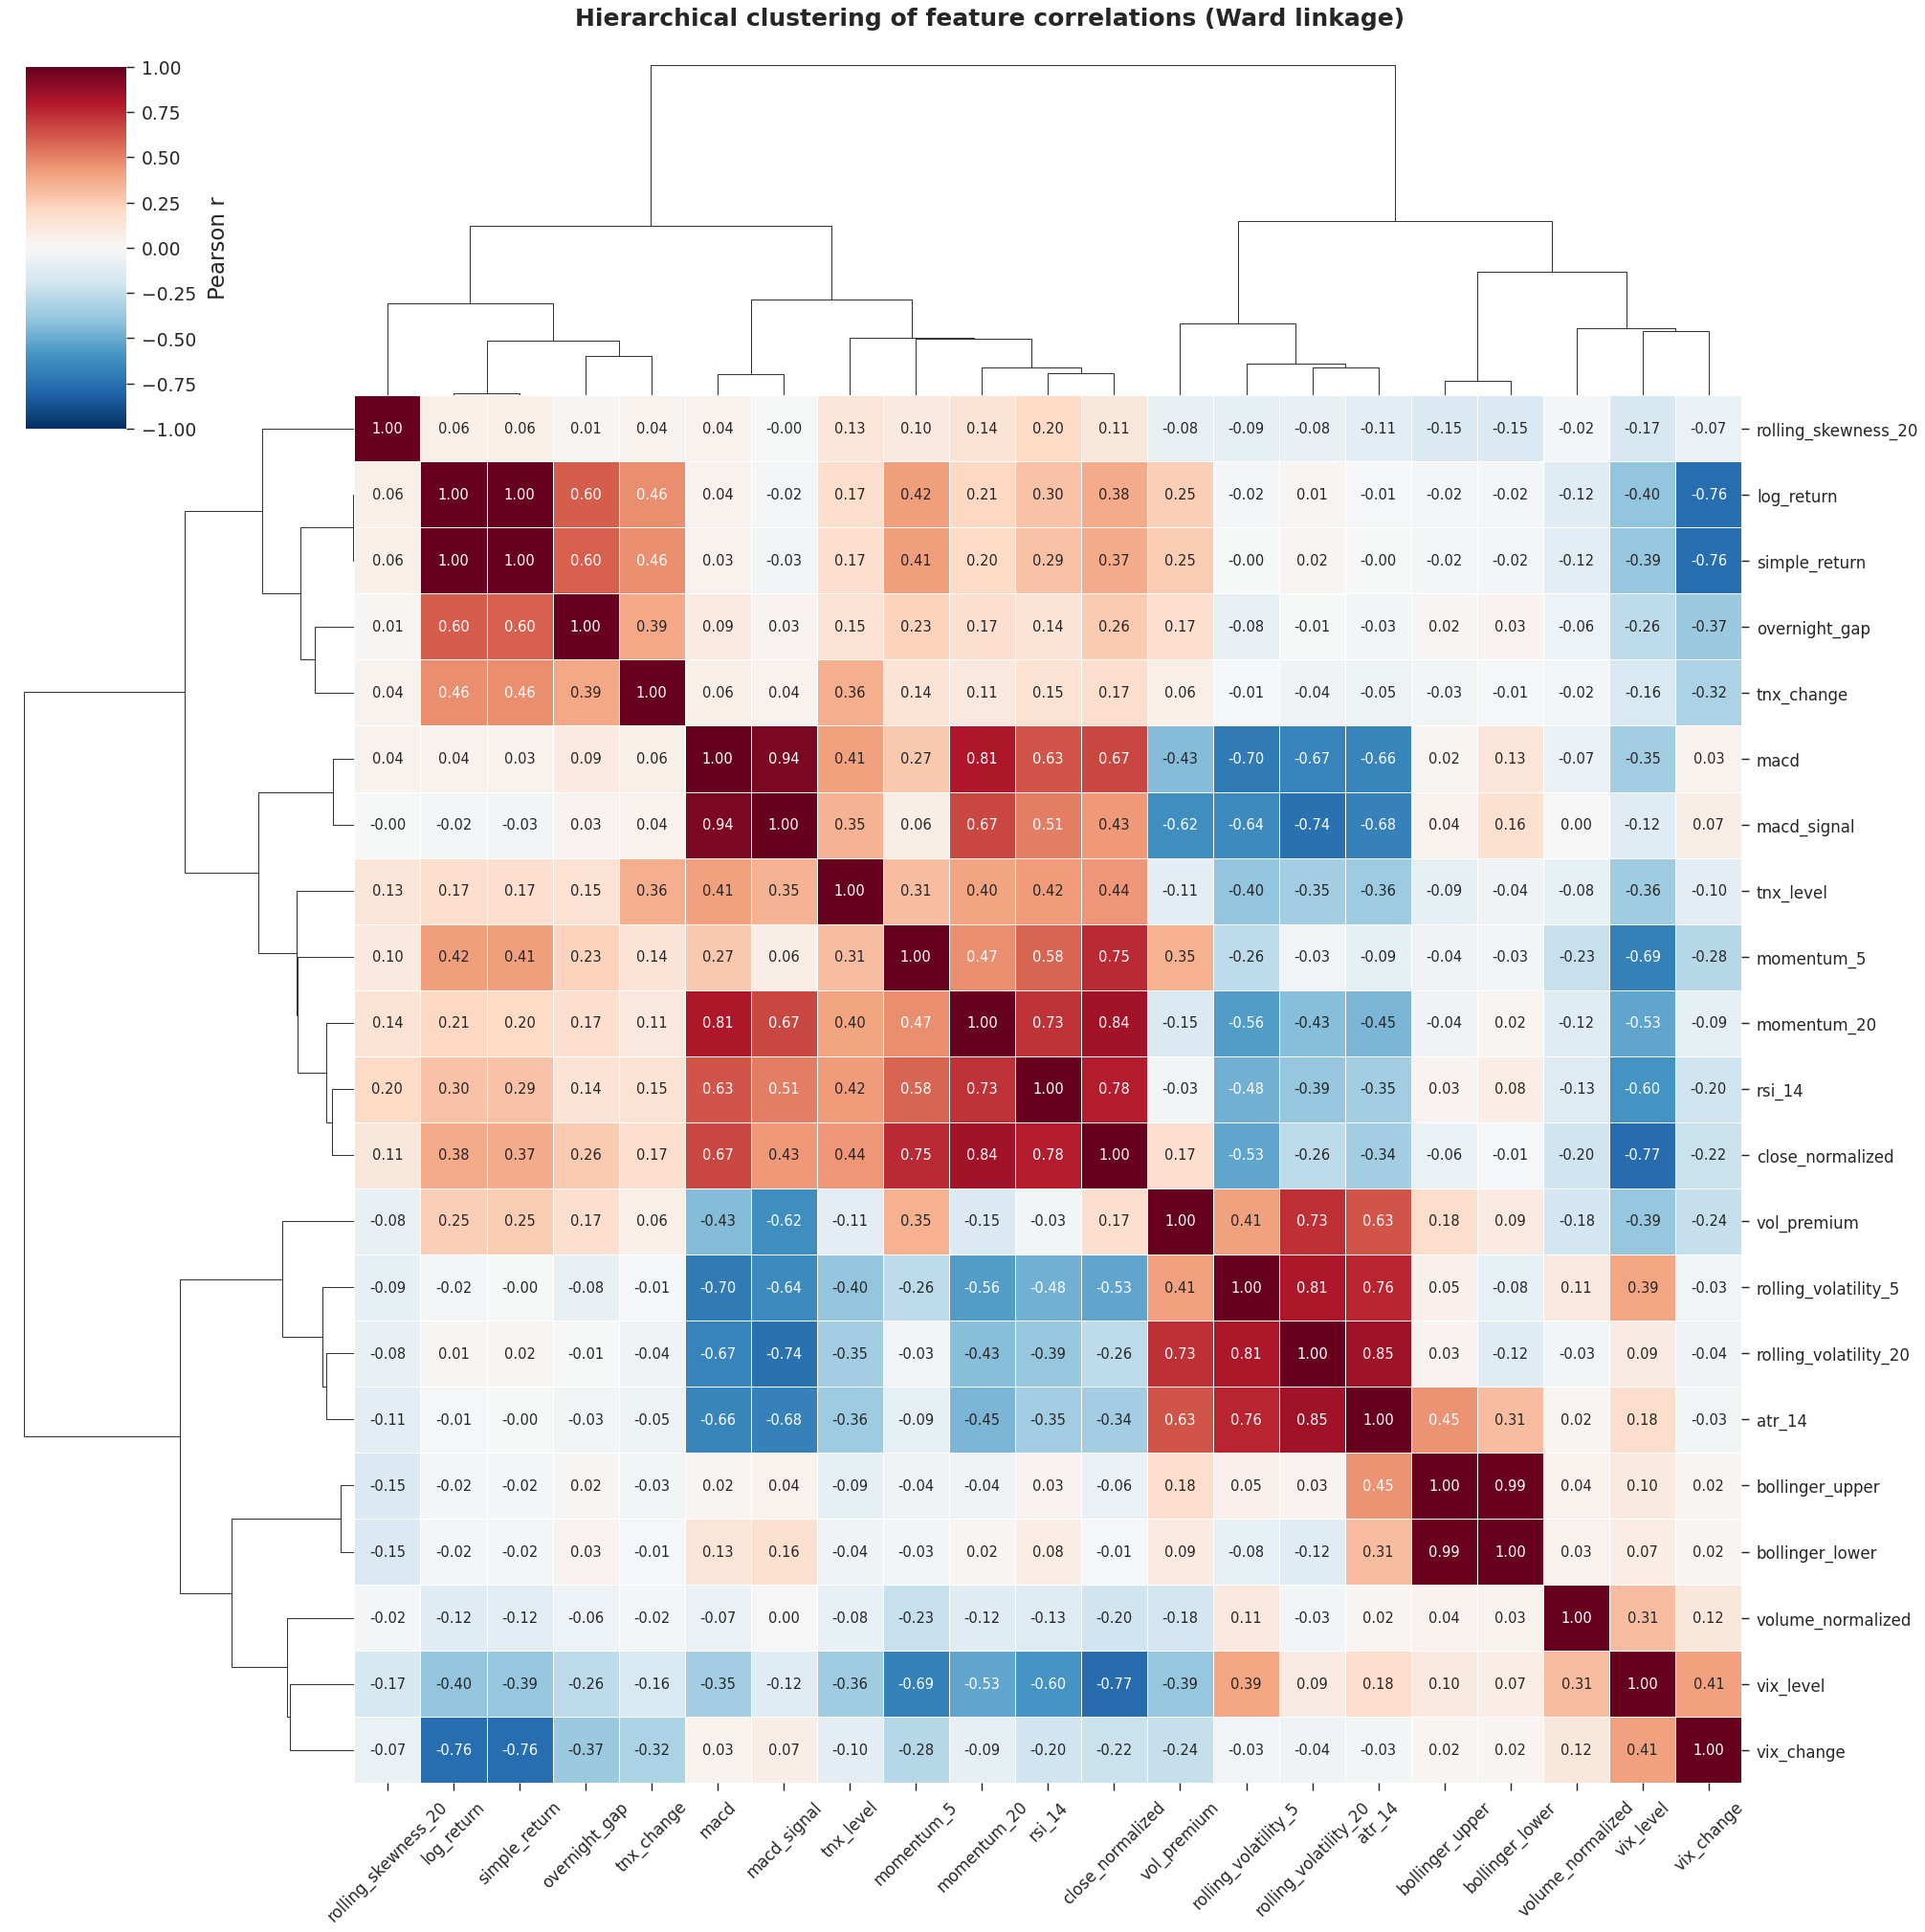

In [ ]:
# Hierarchical Clustermap
g = sns.clustermap(
    corr,
    method='ward',
    metric='euclidean',
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    figsize=(14, 14),
    annot=True, fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.25,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.45},
)
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', labelrotation=45, labelsize=8)
g.ax_heatmap.tick_params(axis='y', labelrotation=0,  labelsize=8)
g.fig.suptitle('Hierarchical clustering of feature correlations (Ward linkage)',
               fontsize=12, fontweight='bold', y=1.01)
g.savefig(FIG_DIR / 'clustermap.png', dpi=300, bbox_inches='tight')
plt.show()

## Variance Inflation Factor (VIF)

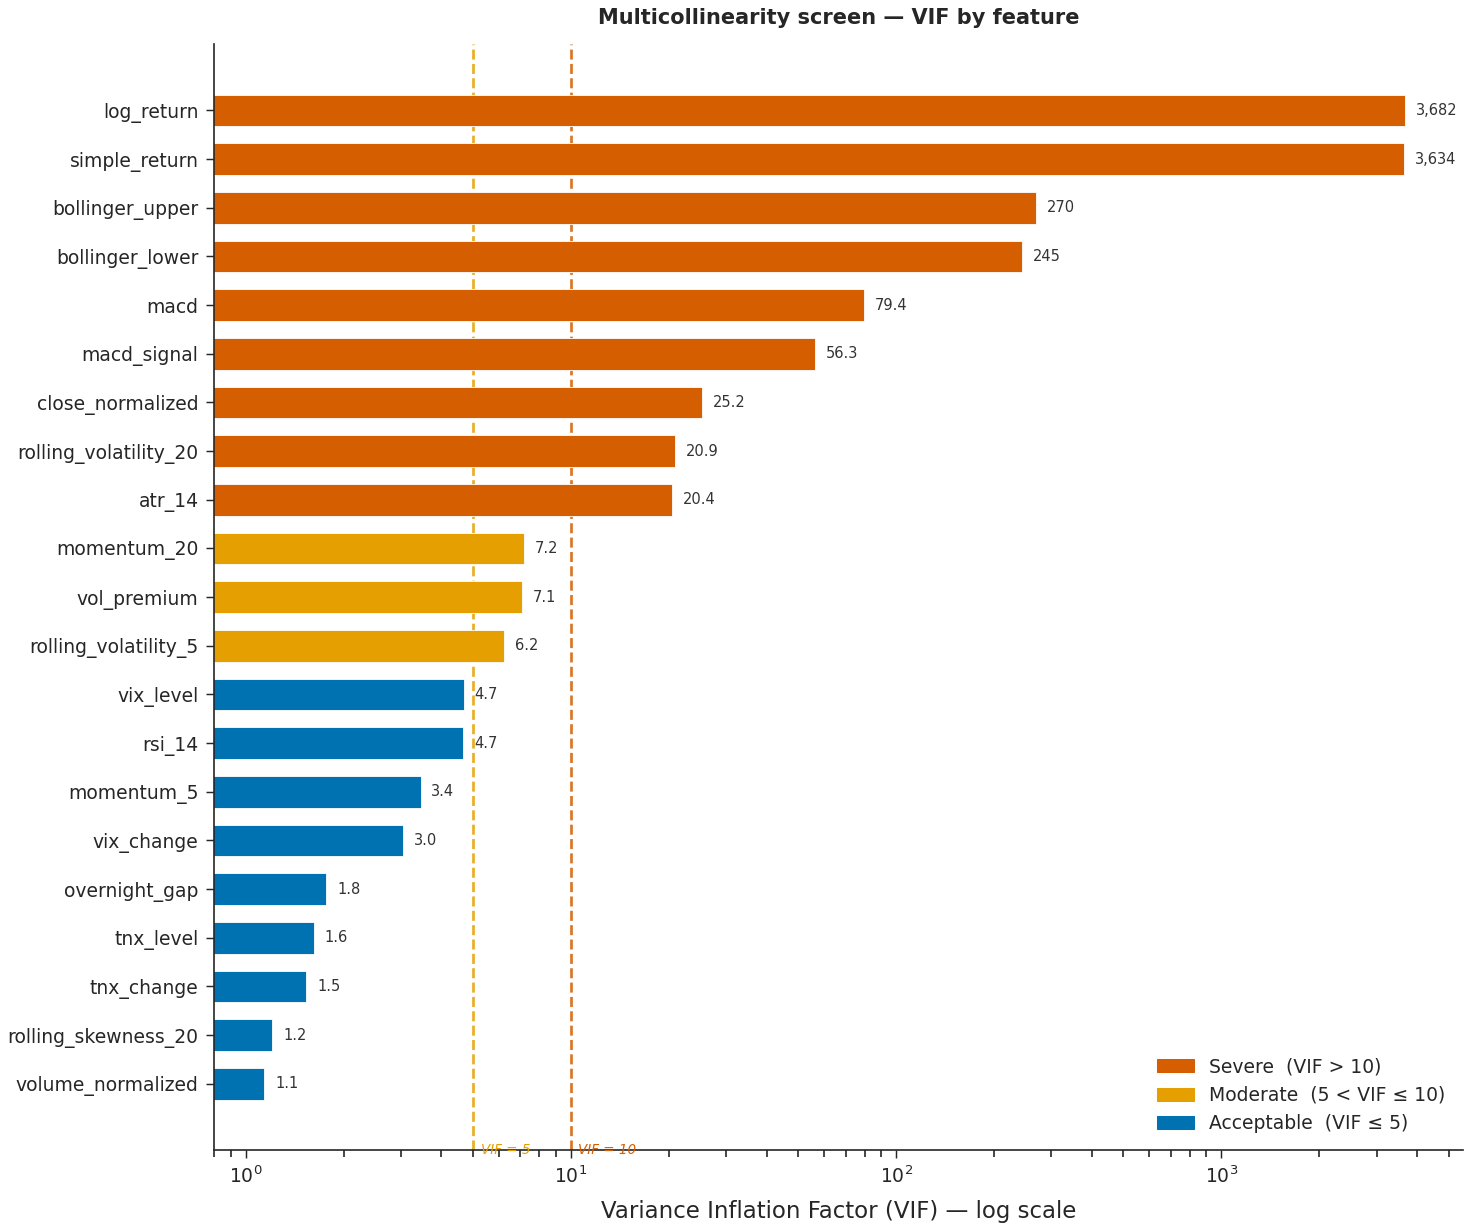

              feature         VIF
           log_return 3681.926330
        simple_return 3634.471371
      bollinger_upper  269.671255
      bollinger_lower  244.581753
                 macd   79.414503
          macd_signal   56.279006
     close_normalized   25.215311
rolling_volatility_20   20.852742
               atr_14   20.424388
          momentum_20    7.169467
          vol_premium    7.090758
 rolling_volatility_5    6.219245
            vix_level    4.679202
               rsi_14    4.663862
           momentum_5    3.448698
           vix_change    3.045864
        overnight_gap    1.771990
            tnx_level    1.619788
           tnx_change    1.537163
  rolling_skewness_20    1.206121
    volume_normalized    1.142025


In [ ]:
# VIF > 5: moderate multicollinearity; VIF > 10: severe
vif_data = pd.DataFrame({
    'feature': FEATURE_COLS,
    'VIF': [
        variance_inflation_factor(Xs_train.values, i)
        for i in range(Xs_train.shape[1])
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

VIF_OK, VIF_MOD, VIF_SEV = '#0072B2', '#E69F00', '#D55E00'
colors = [VIF_SEV if v > 10 else VIF_MOD if v > 5 else VIF_OK
          for v in vif_data['VIF']]

fig, ax = plt.subplots(figsize=(10, max(5, len(vif_data) * 0.40)))
bars = ax.barh(vif_data['feature'], vif_data['VIF'],
               color=colors, edgecolor='white', lw=0.4, height=0.65)

# Log scale: makes extreme outliers (log_return ≈ 3500) and small values both legible
ax.set_xscale('log')
ax.set_xlim(left=0.8)

# Threshold reference lines
ax.axvline(5,  color=VIF_MOD, ls='--', lw=1.3, alpha=0.85, zorder=0)
ax.axvline(10, color=VIF_SEV, ls='--', lw=1.3, alpha=0.85, zorder=0)
# Annotate thresholds at top of plot after invert
ax.invert_yaxis()
ymax = ax.get_ylim()[0]  # after invert, [0] is the bottom of the inverted axis
ax.text(5.3,  ymax - 0.15, 'VIF = 5',  color=VIF_MOD, fontsize=6.5,
        va='top', ha='left', style='italic')
ax.text(10.5, ymax - 0.15, 'VIF = 10', color=VIF_SEV, fontsize=6.5,
        va='top', ha='left', style='italic')

# Value annotations on each bar
for bar, val in zip(bars, vif_data['VIF']):
    label = f'{val:,.0f}' if val >= 100 else f'{val:.1f}'
    ax.text(max(val * 1.08, 1.1), bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left', fontsize=7, color='#333333')

ax.set_xlabel('Variance Inflation Factor (VIF) — log scale')
ax.set_title('Multicollinearity screen — VIF by feature',
             fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color=VIF_SEV, label='Severe  (VIF > 10)'),
    Patch(color=VIF_MOD, label='Moderate  (5 < VIF ≤ 10)'),
    Patch(color=VIF_OK,  label='Acceptable  (VIF ≤ 5)'),
]
ax.legend(handles=legend_elements, frameon=False, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / 'vif.png', dpi=300, bbox_inches='tight')
plt.show()

print(vif_data.to_string(index=False))

## Mutual Information with Target

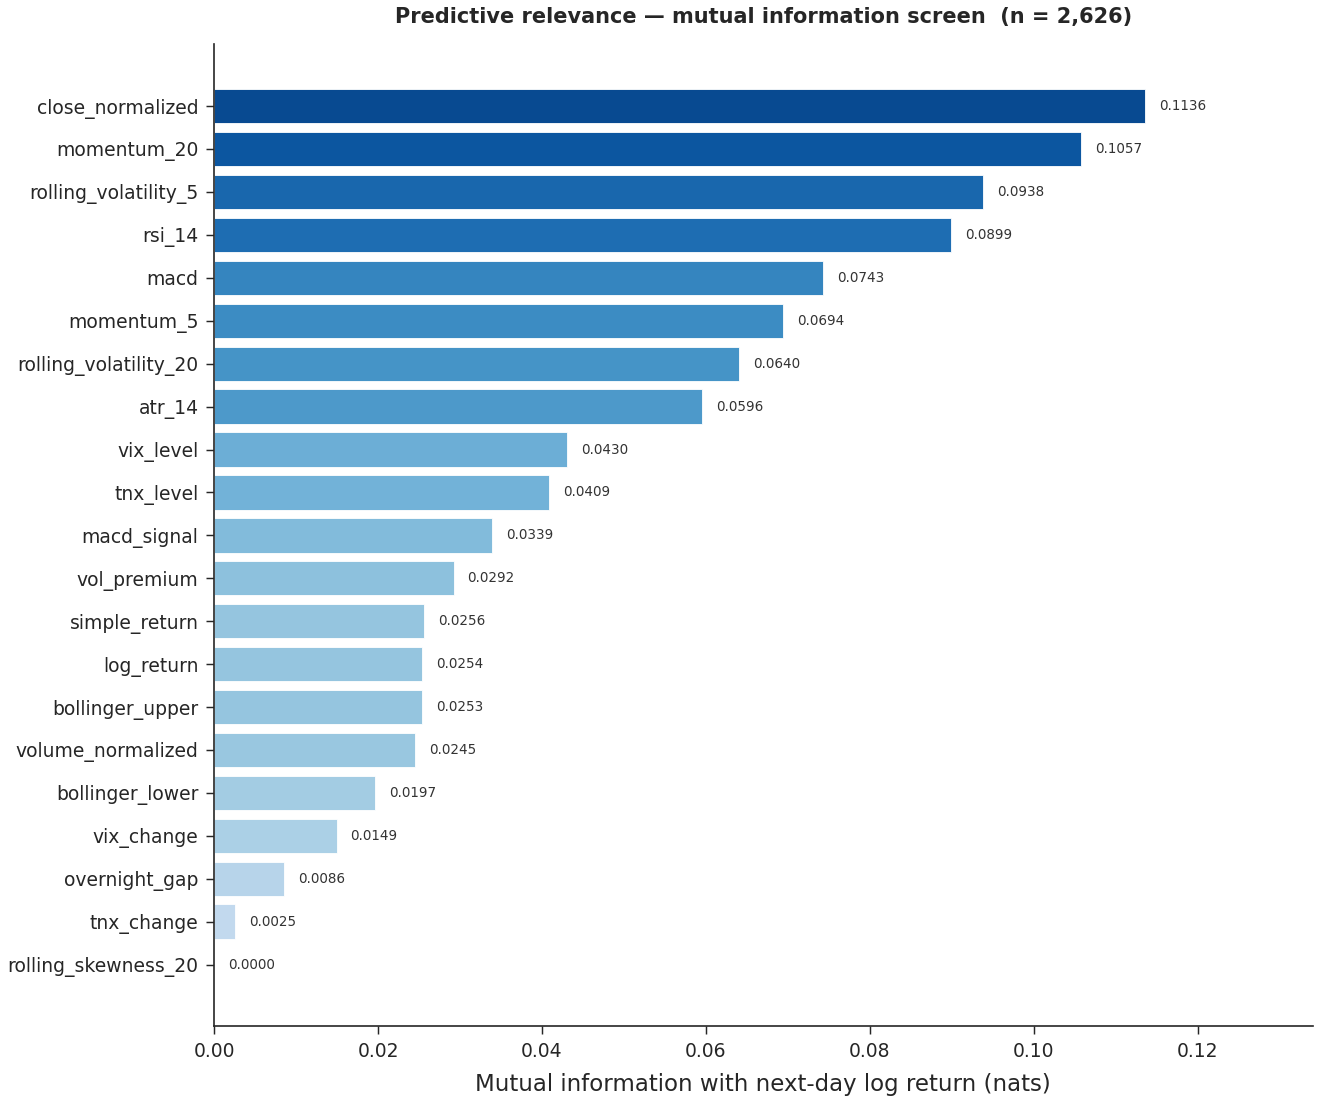

Top predictors:
              feature       MI
     close_normalized 0.113563
          momentum_20 0.105724
 rolling_volatility_5 0.093776
               rsi_14 0.089944
                 macd 0.074284
           momentum_5 0.069436
rolling_volatility_20 0.064045
               atr_14 0.059561
            vix_level 0.043046
            tnx_level 0.040859
          macd_signal 0.033883
          vol_premium 0.029209
        simple_return 0.025574
           log_return 0.025356
      bollinger_upper 0.025321
    volume_normalized 0.024513
      bollinger_lower 0.019669
           vix_change 0.014943
        overnight_gap 0.008556
           tnx_change 0.002512
  rolling_skewness_20 0.000000


In [ ]:
mi_scores = mutual_info_regression(
    Xs_train, y_train, discrete_features=False, random_state=42
)
mi_df = pd.DataFrame({'feature': FEATURE_COLS, 'MI': mi_scores}) \
          .sort_values('MI', ascending=True)

norm_mi = plt.Normalize(mi_df['MI'].min(), mi_df['MI'].max())
bar_colors = plt.cm.Blues(norm_mi(mi_df['MI'].values) * 0.65 + 0.25)

fig, ax = plt.subplots(figsize=(9, max(4, len(mi_df) * 0.36)))
bars = ax.barh(mi_df['feature'], mi_df['MI'],
               color=bar_colors, edgecolor='white', lw=0.4)

# Value annotations on each bar
for bar, val in zip(bars, mi_df['MI']):
    ax.text(val + mi_df['MI'].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=6.5, color='#333333')

ax.set_xlabel('Mutual information with next-day log return (nats)')
ax.set_title(
    f'Predictive relevance — mutual information screen  (n = {len(X_train):,})',
    fontsize=10, fontweight='bold',
)
ax.set_xlim(right=mi_df['MI'].max() * 1.18)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / 'mutual_info.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top predictors:')
print(mi_df.sort_values('MI', ascending=False).to_string(index=False))

## Rolling Predictive Stability

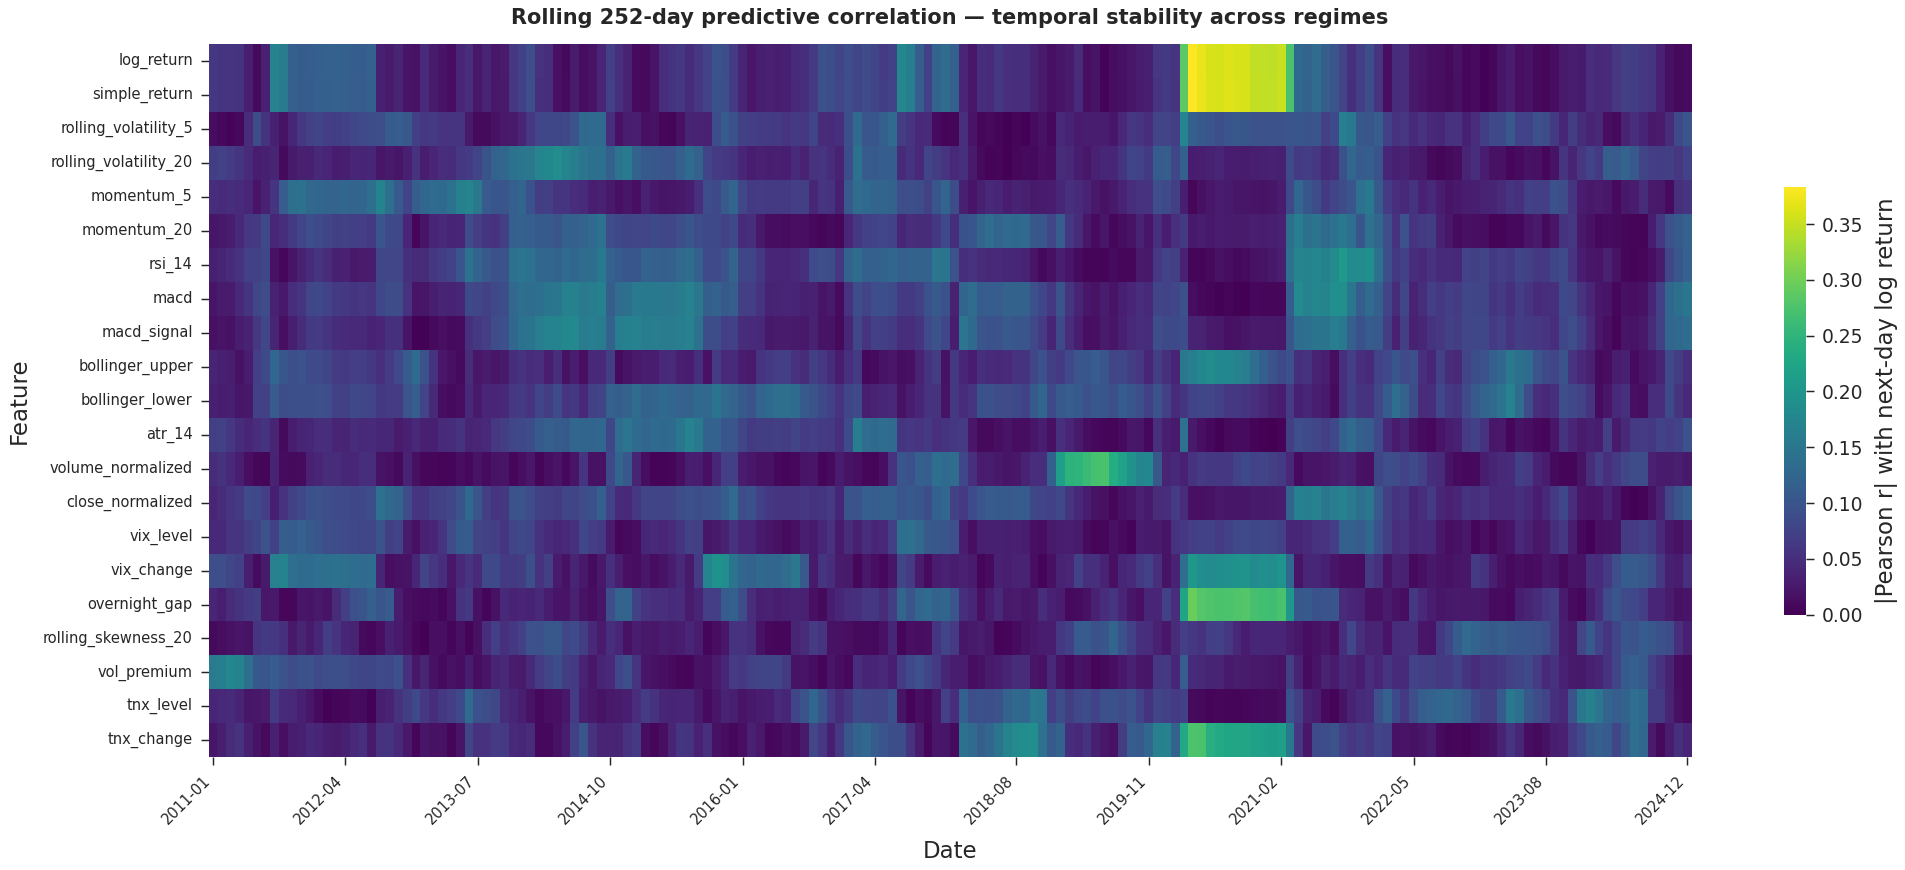

In [ ]:
# Absolute Pearson |r| between each feature and next-day log return,
# computed on a rolling 252-trading-day window and resampled monthly.
# Stable features maintain signal across regimes; volatile features are
# regime-dependent and may hurt walk-forward generalisation.

roll_corr = pd.DataFrame({
    feat: X[feat].rolling(252).corr(y).abs()
    for feat in FEATURE_COLS
}).dropna()

roll_corr_monthly = roll_corr.resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    roll_corr_monthly.T,
    cmap='viridis',
    vmin=0,
    vmax=roll_corr_monthly.values.max(),
    ax=ax,
    linewidths=0,
    cbar_kws={'label': '|Pearson r| with next-day log return', 'shrink': 0.6},
)
ax.set_xlabel('Date')
ax.set_ylabel('Feature')
ax.set_title(
    'Rolling 252-day predictive correlation — temporal stability across regimes',
    fontsize=10, fontweight='bold',
)
n_ticks = 12
tick_locs = np.linspace(0, len(roll_corr_monthly) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_locs + 0.5)
ax.set_xticklabels(
    [str(roll_corr_monthly.index[i])[:7] for i in tick_locs],
    rotation=45, ha='right', fontsize=7,
)
ax.tick_params(axis='y', labelsize=7, labelrotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rolling_corr_stability.png', dpi=300, bbox_inches='tight')
plt.show()

## VIX Regime Feature Distributions

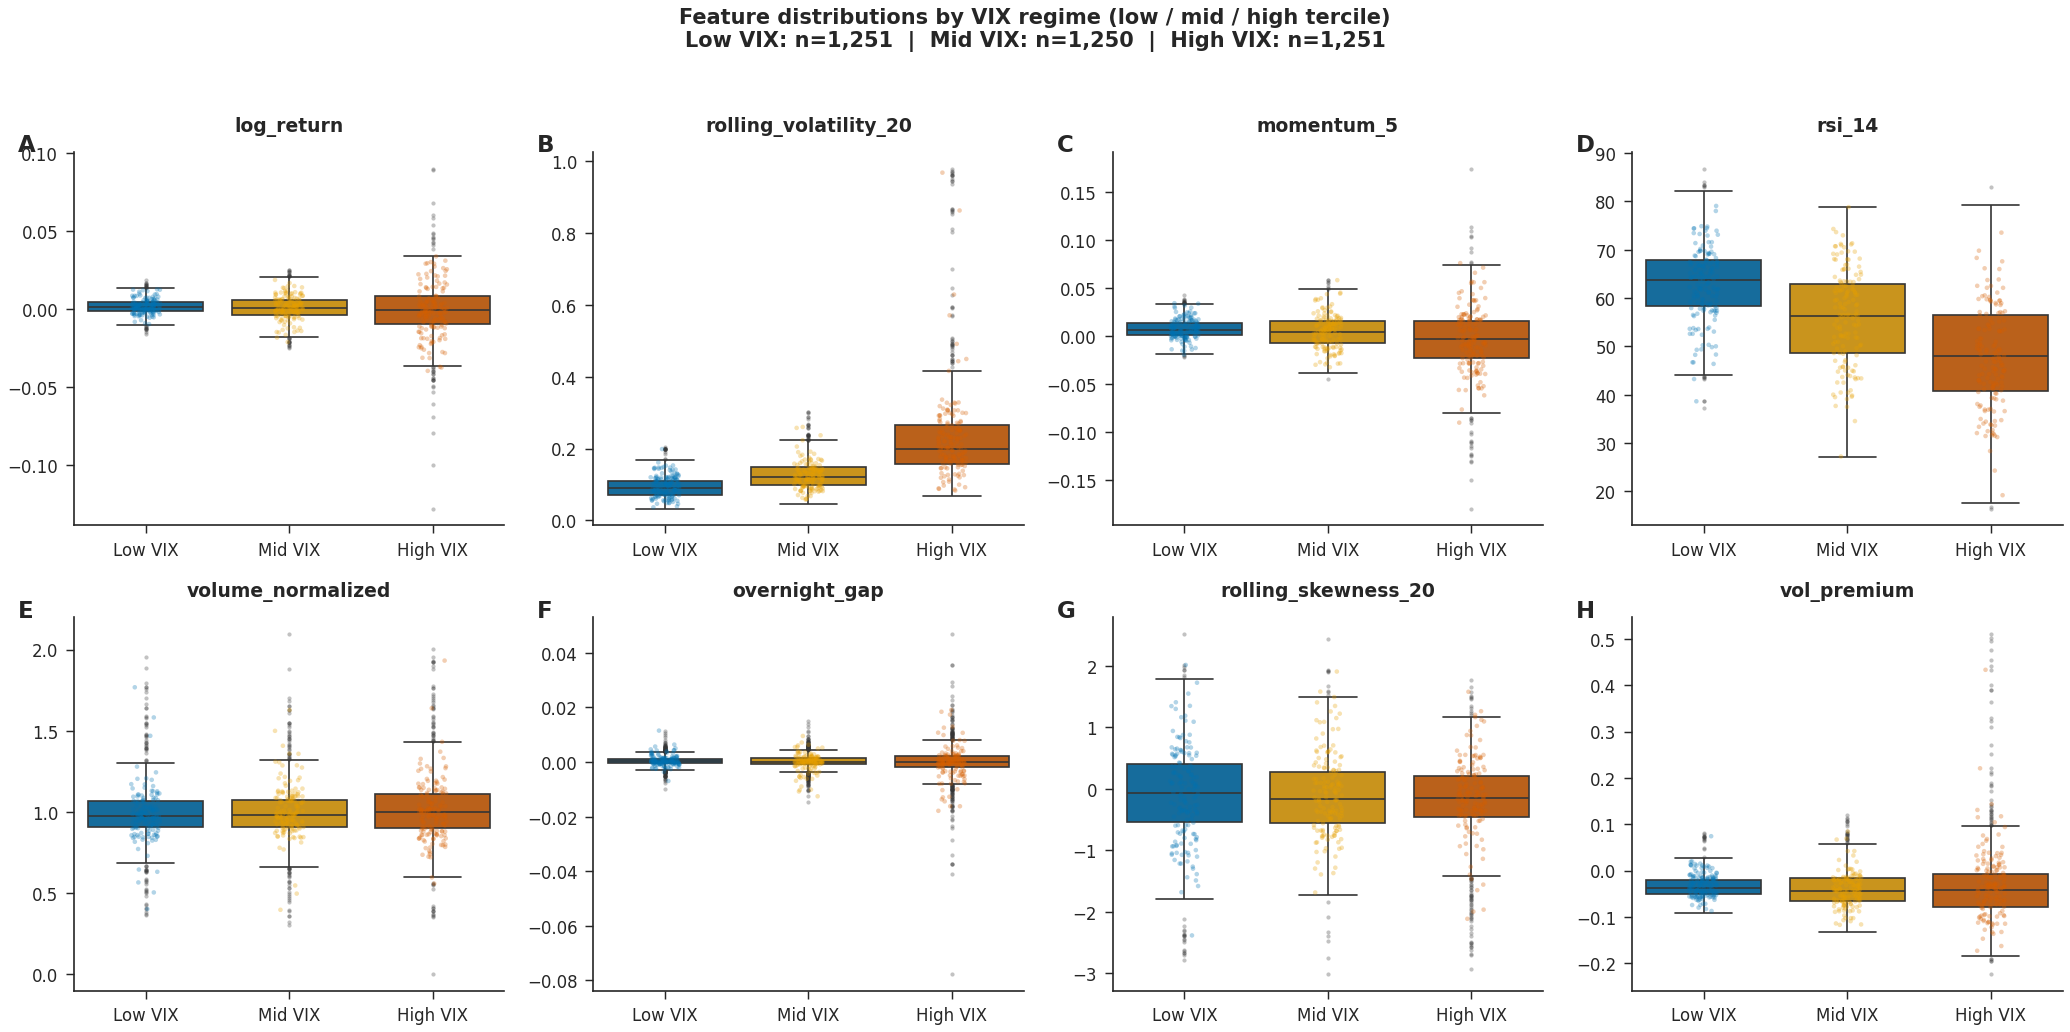

In [10]:
# ── 5c. Feature distributions by VIX regime ───────────────────────────
X_regime = X.copy()
X_regime['_vix_raw'] = vix.reindex(X.index).ffill().bfill()
X_regime['regime'] = pd.qcut(
    X_regime['_vix_raw'], q=3, labels=['Low VIX', 'Mid VIX', 'High VIX']
)

regime_counts = X_regime['regime'].value_counts().sort_index()

regime_features = [
    f for f in [
        'log_return', 'rolling_volatility_20', 'momentum_5', 'rsi_14',
        'volume_normalized', 'overnight_gap', 'rolling_skewness_20', 'vol_premium',
    ]
    if f in FEATURE_COLS
]

# Sample individual points for strip overlay (150 per regime keeps plot readable)
STRIP_N = 150
X_sample = pd.concat([
    grp.sample(min(len(grp), STRIP_N), random_state=42)
    for _, grp in X_regime.groupby('regime', observed=True)
]).reset_index(drop=True)

ncols = 4
nrows = -(-len(regime_features) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.4))
axes = axes.flatten()
palette = {'Low VIX': '#0072B2', 'Mid VIX': '#E69F00', 'High VIX': '#D55E00'}
order = ['Low VIX', 'Mid VIX', 'High VIX']
panel_letters = 'ABCDEFGHIJKLMNOP'

for i, feat in enumerate(regime_features):
    ax = axes[i]
    sns.boxplot(
        data=X_regime, x='regime', y=feat, order=order,
        hue='regime', palette=palette, legend=False,
        ax=ax, linewidth=0.8,
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
    )
    sns.stripplot(
        data=X_sample, x='regime', y=feat, order=order,
        hue='regime', palette=palette, legend=False,
        ax=ax, size=2.2, alpha=0.3, jitter=True,
    )
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)
    ax.text(-0.13, 1.05, panel_letters[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    sns.despine(ax=ax)

for j in range(len(regime_features), len(axes)):
    axes[j].set_visible(False)

n_str = '  |  '.join(f'{r}: n={regime_counts[r]:,}' for r in order)
fig.suptitle(
    f'Feature distributions by VIX regime (low / mid / high tercile)\n{n_str}',
    fontsize=10, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'vix_regime_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## Intrinsic Dimensionality

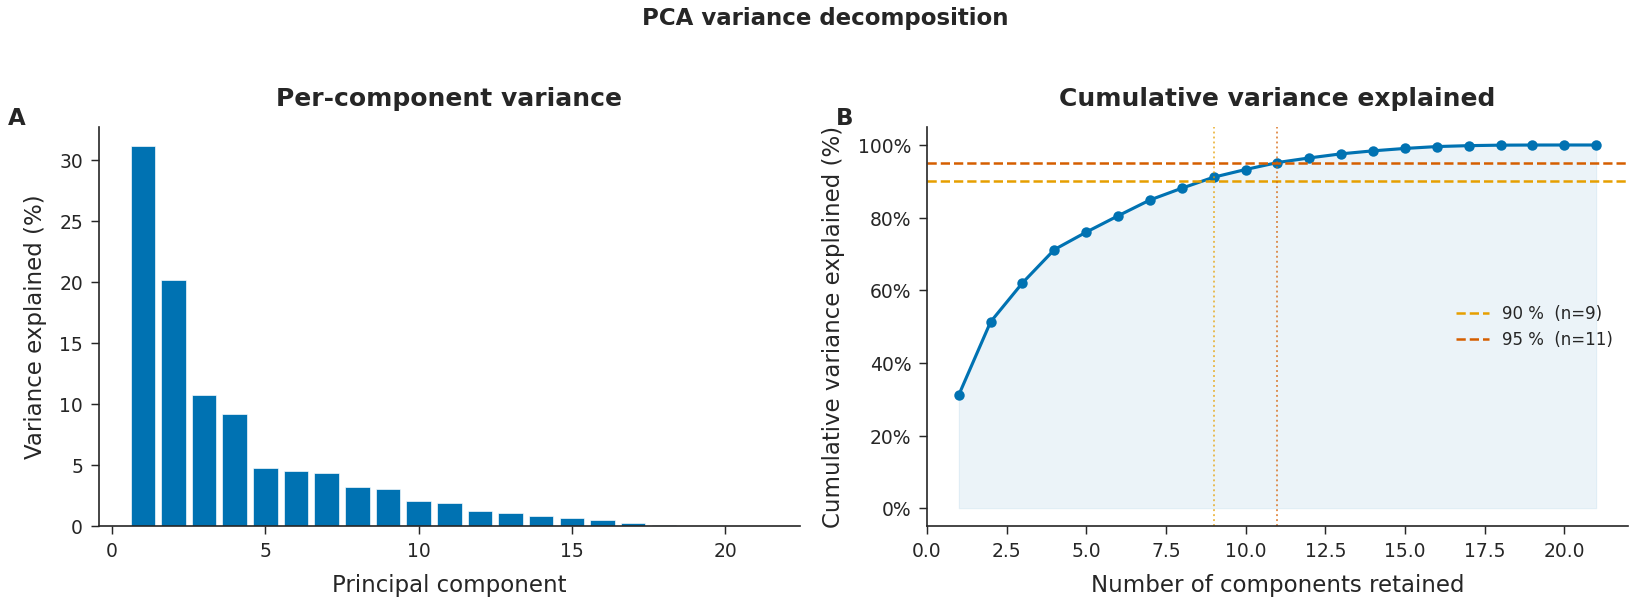

Components needed for 90% variance: 9
Components needed for 95% variance: 11
Intrinsic dimensionality ≈ 9–11 out of 21 features


In [ ]:
pca = PCA(n_components=len(FEATURE_COLS)).fit(Xs_train)
cum_var = np.cumsum(pca.explained_variance_ratio_)

n_90 = int(np.searchsorted(cum_var, 0.90)) + 1
n_95 = int(np.searchsorted(cum_var, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A — per-component scree
axes[0].bar(
    range(1, len(FEATURE_COLS) + 1),
    pca.explained_variance_ratio_ * 100,
    color='#0072B2', edgecolor='white', lw=0.3,
)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Per-component variance', fontweight='bold')
axes[0].text(-0.13, 1.05, 'A', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', va='top')
sns.despine(ax=axes[0])

# Panel B — cumulative variance with crossing-point annotations
axes[1].plot(range(1, len(FEATURE_COLS) + 1), cum_var * 100,
             marker='o', ms=4, color='#0072B2', lw=1.5)
axes[1].axhline(90, color='#E69F00', ls='--', lw=1.2, label=f'90 %  (n={n_90})')
axes[1].axhline(95, color='#D55E00', ls='--', lw=1.2, label=f'95 %  (n={n_95})')
axes[1].axvline(n_90, color='#E69F00', ls=':', lw=0.9, alpha=0.7)
axes[1].axvline(n_95, color='#D55E00', ls=':', lw=0.9, alpha=0.7)
axes[1].fill_between(range(1, len(FEATURE_COLS) + 1), cum_var * 100,
                     alpha=0.08, color='#0072B2')
axes[1].set_xlabel('Number of components retained')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('Cumulative variance explained', fontweight='bold')
axes[1].legend(frameon=False, fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].text(-0.13, 1.05, 'B', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', va='top')
sns.despine(ax=axes[1])

plt.suptitle('PCA variance decomposition', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Components needed for 90% variance: {n_90}')
print(f'Components needed for 95% variance: {n_95}')
print(f'Intrinsic dimensionality ≈ {n_90}–{n_95} out of {len(FEATURE_COLS)} features')

## LightGBM Feature Importance

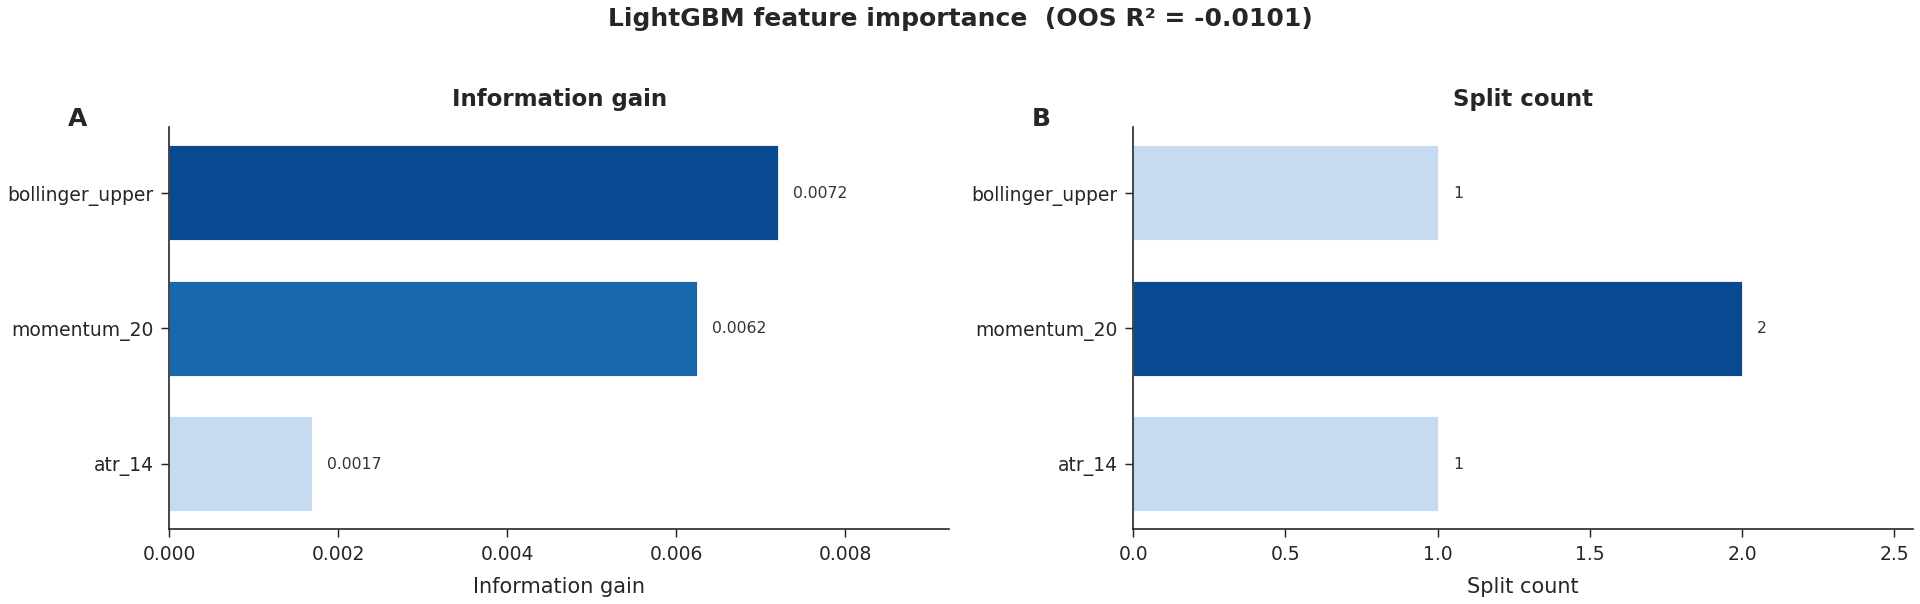

LightGBM OOS R² = -0.0101  |  3/21 features used by model
              feature     gain  split
      bollinger_upper 0.007208      1
          momentum_20 0.006249      2
               atr_14 0.001683      1
           log_return 0.000000      0
    volume_normalized 0.000000      0
            tnx_level 0.000000      0
          vol_premium 0.000000      0
  rolling_skewness_20 0.000000      0
        overnight_gap 0.000000      0
           vix_change 0.000000      0
            vix_level 0.000000      0
     close_normalized 0.000000      0
      bollinger_lower 0.000000      0
        simple_return 0.000000      0
          macd_signal 0.000000      0
                 macd 0.000000      0
               rsi_14 0.000000      0
           momentum_5 0.000000      0
rolling_volatility_20 0.000000      0
 rolling_volatility_5 0.000000      0
           tnx_change 0.000000      0


In [ ]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=4, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42, verbose=-1,
)
lgb_model.fit(
    Xs_train, y_train,
    eval_set=[(Xs_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

importance_gain = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain':    lgb_model.booster_.feature_importance(importance_type='gain'),
    'split':   lgb_model.booster_.feature_importance(importance_type='split'),
})

# Keep only features used by the model (avoids empty-bar clutter)
importance_gain = importance_gain[
    (importance_gain['gain'] > 0) | (importance_gain['split'] > 0)
].sort_values('gain', ascending=True).reset_index(drop=True)

oos_r2 = r2_score(y_test, lgb_model.predict(Xs_test))
n_shown = len(importance_gain)

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, n_shown * 0.45)))
for ax, col, title, plab in zip(
        axes,
        ['gain', 'split'],
        ['Information gain', 'Split count'],
        ['A', 'B'],
):
    vals = importance_gain[col].values
    norm_v = plt.Normalize(vals.min(), vals.max())
    colors_v = plt.cm.Blues(norm_v(vals) * 0.65 + 0.25)
    bars = ax.barh(importance_gain['feature'], vals,
                   color=colors_v, edgecolor='white', lw=0.4, height=0.7)
    for bar, val in zip(bars, vals):
        if val > 0:
            fmt = f'{val:,.0f}' if col == 'split' else f'{val:.4f}'
            ax.text(val + vals.max() * 0.025,
                    bar.get_y() + bar.get_height() / 2,
                    fmt, va='center', ha='left', fontsize=7.5, color='#333333')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(title, fontsize=10)
    ax.set_xlim(right=vals.max() * 1.28)
    ax.text(-0.13, 1.05, plab, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top')
    sns.despine(ax=ax)

plt.suptitle(
    f'LightGBM feature importance  (OOS R² = {oos_r2:.4f})',
    fontsize=12, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'LightGBM OOS R² = {oos_r2:.4f}  |  {n_shown}/{len(FEATURE_COLS)} features used by model')
full_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain':    lgb_model.booster_.feature_importance(importance_type='gain'),
    'split':   lgb_model.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)
print(full_imp.to_string(index=False))

## Single-Feature Ablation (OOS R²)

In [ ]:
# For each feature f: train LightGBM on all features EXCEPT f, record OOS R².
# Δ R² = baseline_R² - leave_one_out_R²
# High Δ R² → feature is load-bearing; near-zero Δ R² → safe to drop.

def train_lgbm_r2(X_tr, X_te, y_tr, y_te):
    m = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1,
    )
    m.fit(X_tr, y_tr,
          eval_set=[(X_te, y_te)],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return r2_score(y_te, m.predict(X_te))

baseline_r2 = train_lgbm_r2(Xs_train, Xs_test, y_train, y_test)

ablation_results = []
for feat in FEATURE_COLS:
    drop_cols = [c for c in FEATURE_COLS if c != feat]
    r2 = train_lgbm_r2(
        Xs_train[drop_cols], Xs_test[drop_cols], y_train, y_test
    )
    delta = baseline_r2 - r2
    ablation_results.append({'feature': feat, 'oos_r2_without': r2, 'delta_r2': delta})
    print(f'  Dropped {feat:30s}  OOS R² = {r2:+.5f}  Δ = {delta:+.5f}')

ablation_df = pd.DataFrame(ablation_results).sort_values('delta_r2', ascending=False)
print(f'\nBaseline OOS R² (all {len(FEATURE_COLS)} features): {baseline_r2:+.5f}')

  Dropped log_return                      OOS R² = -0.01008  Δ = +0.00000
  Dropped simple_return                   OOS R² = -0.01008  Δ = +0.00000
  Dropped rolling_volatility_5            OOS R² = -0.01008  Δ = +0.00000
  Dropped rolling_volatility_20           OOS R² = -0.01008  Δ = +0.00000
  Dropped momentum_5                      OOS R² = -0.01008  Δ = +0.00000
  Dropped momentum_20                     OOS R² = -0.01008  Δ = +0.00000
  Dropped rsi_14                          OOS R² = -0.00989  Δ = -0.00019
  Dropped macd                            OOS R² = -0.00989  Δ = -0.00019
  Dropped macd_signal                     OOS R² = -0.00988  Δ = -0.00019
  Dropped bollinger_upper                 OOS R² = +0.00284  Δ = -0.01292
  Dropped bollinger_lower                 OOS R² = -0.00989  Δ = -0.00019
  Dropped atr_14                          OOS R² = -0.00989  Δ = -0.00019
  Dropped volume_normalized               OOS R² = -0.00989  Δ = -0.00019
  Dropped close_normalized            

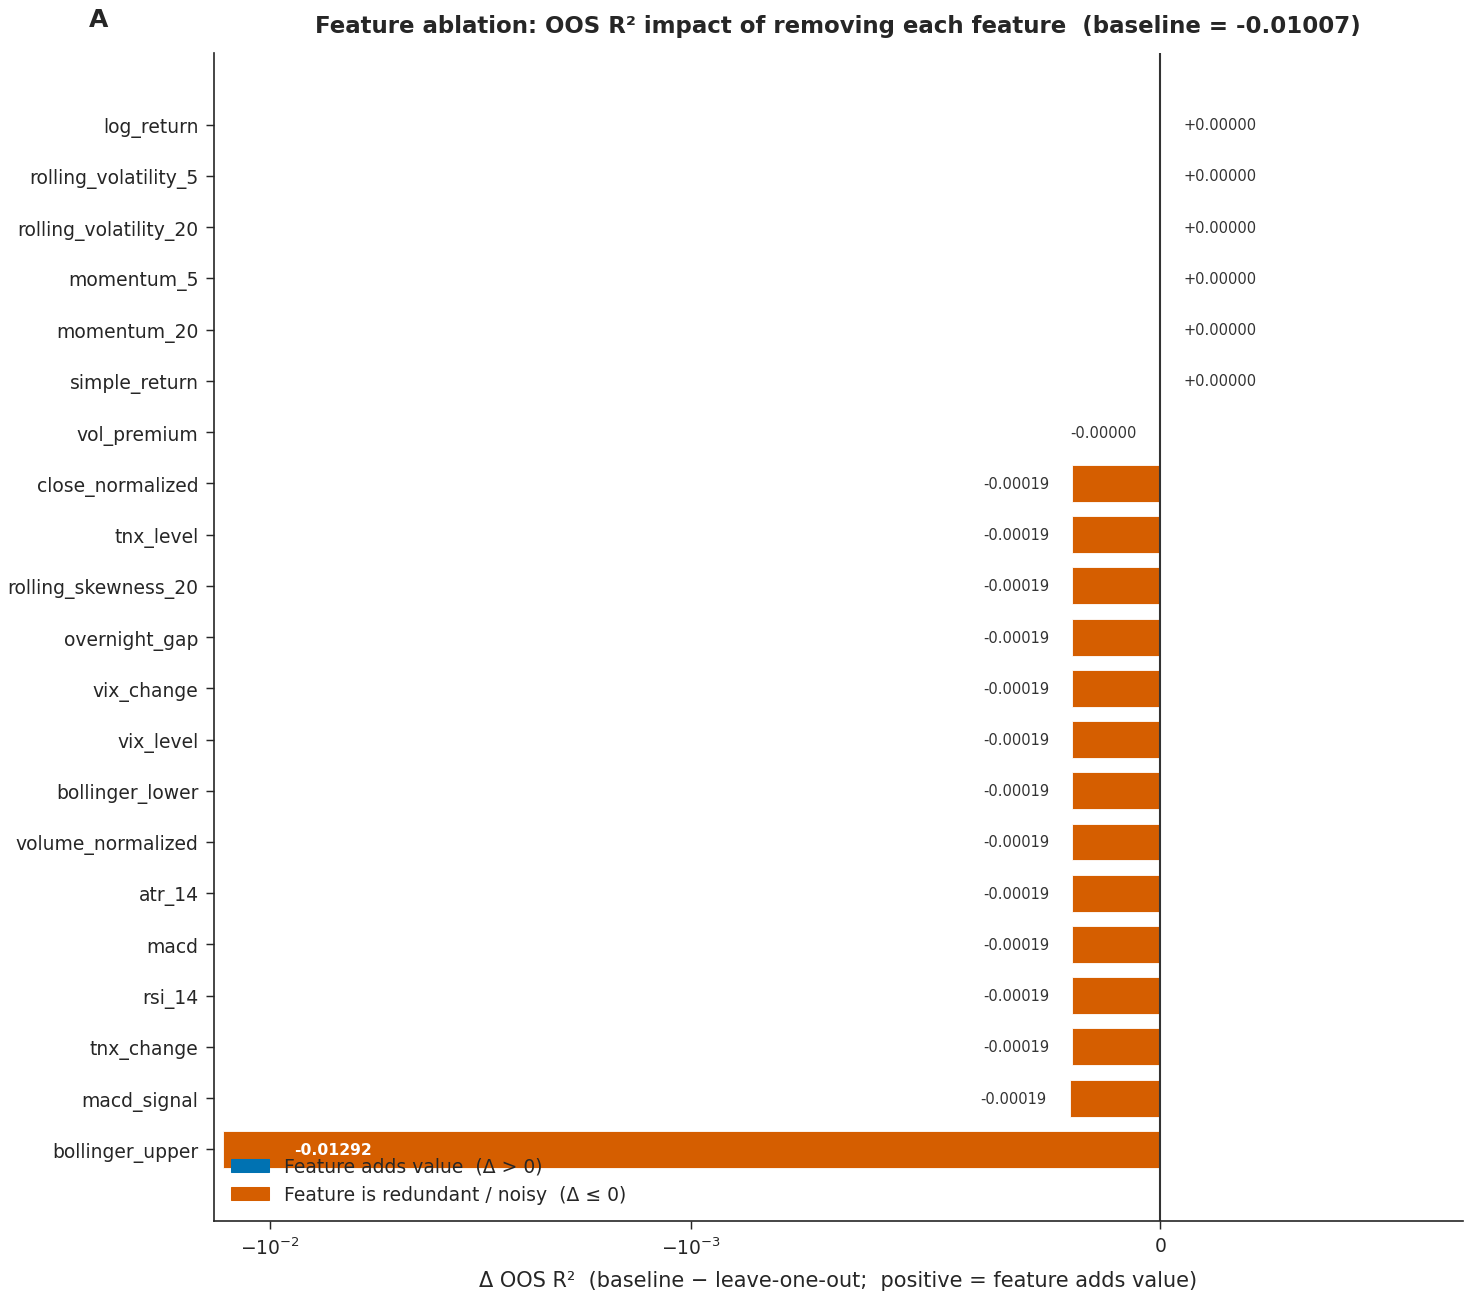

              feature  oos_r2_without      delta_r2
           log_return       -0.010075  2.599397e-07
 rolling_volatility_5       -0.010075  2.599397e-07
rolling_volatility_20       -0.010075  2.599397e-07
           momentum_5       -0.010075  2.599397e-07
          momentum_20       -0.010075  2.599397e-07
        simple_return       -0.010075  2.599397e-07
          vol_premium       -0.010074 -4.725540e-07
     close_normalized       -0.009888 -1.868987e-04
            tnx_level       -0.009888 -1.868987e-04
  rolling_skewness_20       -0.009888 -1.868987e-04
        overnight_gap       -0.009888 -1.868987e-04
           vix_change       -0.009888 -1.868987e-04
            vix_level       -0.009888 -1.868987e-04
      bollinger_lower       -0.009888 -1.868987e-04
    volume_normalized       -0.009888 -1.868987e-04
               atr_14       -0.009888 -1.868987e-04
                 macd       -0.009888 -1.868987e-04
               rsi_14       -0.009888 -1.868987e-04
           t

In [ ]:
abl_colors = [
    '#0072B2' if d > 0 else '#D55E00'
    for d in ablation_df['delta_r2']
]

fig, ax = plt.subplots(figsize=(10, max(5, len(ablation_df) * 0.42)))
bars = ax.barh(ablation_df['feature'], ablation_df['delta_r2'],
               color=abl_colors, edgecolor='white', lw=0.4, height=0.72)
ax.axvline(0, color='#333333', lw=1.0)

# Symlog scale: linear region around 0, log elsewhere — handles extreme outliers
ax.set_xscale('symlog', linthresh=0.001)

# Value annotations — placed inside bar for the dominant outlier, outside for small bars
for bar, val in zip(bars, ablation_df['delta_r2']):
    x_range = ablation_df['delta_r2'].abs().max()
    if abs(val) > 0.005:
        # Large bar: annotate inside
        ax.text(val * 0.55, bar.get_y() + bar.get_height() / 2,
                f'{val:+.5f}', va='center', ha='center', fontsize=7.5,
                color='white', fontweight='bold')
    elif abs(val) > 1e-7:
        offset = 0.00005 if val >= 0 else -0.00005
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:+.5f}', va='center', ha=ha, fontsize=7, color='#333333')

ax.set_xlabel('Δ OOS R²  (baseline − leave-one-out;  positive = feature adds value)', fontsize=10)
ax.set_title(
    f'Feature ablation: OOS R² impact of removing each feature  '
    f'(baseline = {baseline_r2:+.5f})',
    fontsize=11, fontweight='bold',
)
ax.invert_yaxis()
ax.text(-0.10, 1.04, 'A', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top')

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color='#0072B2', label='Feature adds value  (Δ > 0)'),
        Patch(color='#D55E00', label='Feature is redundant / noisy  (Δ ≤ 0)'),
    ],
    frameon=False, fontsize=9, loc='lower left',
)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ablation.png', dpi=300, bbox_inches='tight')
plt.show()

print(ablation_df[['feature', 'oos_r2_without', 'delta_r2']].to_string(index=False))